In [ ]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

# -----------------------------
# 1. Generate Synthetic Dataset
# -----------------------------
signatures = [
    "ASA-6-302013","ASA-6-302014","ASA-6-302015","ASA-6-302016",
    "FTD-6-302015","FTD-6-302014","FTD-6-302016",
    "ASA-4-106023","ASA-6-106100","ASA-6-106102","ASA-6-106103",
    "ASA-6-605005","ASA-5-111008","ASA-5-111010",
    "FTD-6-430003","FTD-6-430002"
]

hosts   = ["fw1.site","fw2.site"]
ifaces  = ["inside","outside","dmz"]
zones   = ["DC","Branch","Inside","Outside"]
users   = ["alice","bob","charlie","dave","eve","mallory","unknown"]
actions = ["allow","deny","count","observe","vpn","teardown"]
protocols = ["TCP","UDP","ICMP"]

def rand_ip():
    return ".".join(str(random.randint(1, 254)) for _ in range(4))

def rand_port():
    return random.randint(1024,65535)

rows = []
start = datetime(2025,8,10,12,20,0)

for sig in signatures:
    for _ in range(600):   # ~9600 rows total (smaller size for demo)
        ts = start + timedelta(seconds=random.randint(0, 50000))
        host = random.choice(hosts)
        severity = int(sig.split("-")[1])
        msg_id_code = int(sig.split("-")[2])
        conn_id = random.randint(10000,99999)
        ingress_iface = random.choice(ifaces)
        egress_iface = random.choice(ifaces)
        ingress_zone = random.choice(zones)
        egress_zone = random.choice(zones)
        src_ip = rand_ip()
        dst_ip = rand_ip()
        src_port = rand_port()
        dst_port = rand_port()
        protocol = random.choice(protocols)
        protocol_num = {"TCP":6,"UDP":17,"ICMP":1}[protocol]
        user = random.choice(users)
        action = random.choice(actions)

        # build message
        message = f"%{sig}: Example log message conn {conn_id} {protocol} {src_ip}:{src_port}->{dst_ip}:{dst_port}"

        rows.append([ts,host,sig,severity,conn_id,ingress_iface,egress_iface,
                     ingress_zone,egress_zone,src_ip,dst_ip,src_port,dst_port,
                     protocol,user,action,message,msg_id_code,protocol_num])

df = pd.DataFrame(rows, columns=[
    "timestamp","host","msg_id","severity","conn_id",
    "ingress_iface","egress_iface","ingress_zone","egress_zone",
    "src_ip","dst_ip","src_port","dst_port","protocol",
    "user","action","message","msg_id_code","protocol_num"
])

# Derive time features
df["hour"]   = df["timestamp"].dt.hour
df["minute"] = df["timestamp"].dt.minute
df["weekday"]= df["timestamp"].dt.weekday

# ----------------------------------------
# 2. Rule-based Anomaly Label Assignment
# ----------------------------------------
def assign_anomaly(row):
    if row["action"] in ["deny","teardown","vpn"]:
        return 1, "blocked_or_vpn"
    if row["severity"] <= 4:
        return 1, "low_severity_alert"
    if row["hour"] < 5 or row["hour"] > 22:
        return 1, "odd_hour_activity"
    return 0, np.nan

df[["is_anomaly","anomaly_type"]] = df.apply(assign_anomaly, axis=1, result_type="expand")

print(df["is_anomaly"].value_counts())

# ----------------------------------------
# 3. ML Pipeline (RandomForest)
# ----------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Target
y = df["is_anomaly"]

# Drop non-ML columns
X = df.drop(columns=["is_anomaly","anomaly_type","message","timestamp"])

# Separate categorical and numeric
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols)
    ]
)

# Build pipeline
clf = Pipeline(steps=[
    ("pre", preprocessor),
    ("model", RandomForestClassifier(n_estimators=200, random_state=42))
])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Train model
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))


is_anomaly
1.0    6103
0.0    3497
Name: count, dtype: int64
              precision    recall  f1-score   support

         0.0       0.91      1.00      0.96       699
         1.0       1.00      0.95      0.97      1221

    accuracy                           0.97      1920
   macro avg       0.96      0.97      0.96      1920
weighted avg       0.97      0.97      0.97      1920



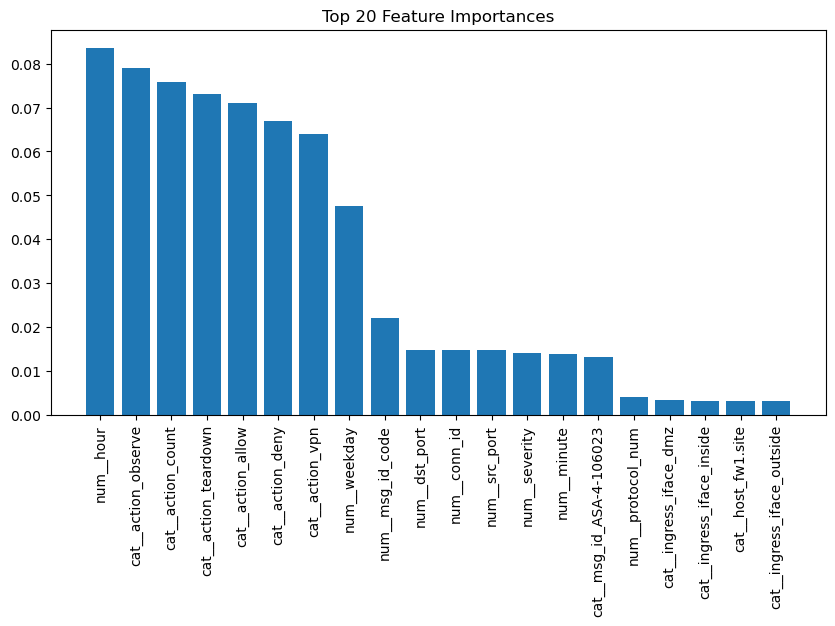

In [ ]:
import matplotlib.pyplot as plt

model = clf.named_steps["model"]
feature_names = clf.named_steps["pre"].get_feature_names_out()
importances = model.feature_importances_

sorted_idx = importances.argsort()[::-1]
plt.figure(figsize=(10,5))
plt.bar(range(20), importances[sorted_idx][:20])
plt.xticks(range(20), feature_names[sorted_idx][:20], rotation=90)
plt.title("Top 20 Feature Importances")
plt.show()

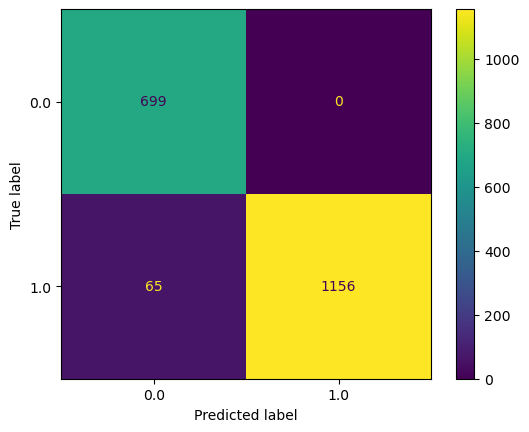

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test)
plt.show()

In [ ]:
df['is_anomaly'].value_counts()

is_anomaly
1.0    6103
0.0    3497
Name: count, dtype: int64

In [ ]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

# -----------------------------
# 1. Generate Synthetic Dataset
# -----------------------------
signatures = [
    "ASA-6-302013","ASA-6-302014","ASA-6-302015","ASA-6-302016",
    "FTD-6-302015","FTD-6-302014","FTD-6-302016",
    "ASA-4-106023","ASA-6-106100","ASA-6-106102","ASA-6-106103",
    "ASA-6-605005","ASA-5-111008","ASA-5-111010",
    "FTD-6-430003","FTD-6-430002"
]

hosts   = ["fw1.site","fw2.site"]
ifaces  = ["inside","outside","dmz"]
zones   = ["DC","Branch","Inside","Outside"]
users   = ["alice","bob","charlie","dave","eve","mallory","unknown"]
actions = ["allow","deny","count","observe","vpn","teardown"]
protocols = ["TCP","UDP","ICMP"]

def rand_ip():
    return ".".join(str(random.randint(1, 254)) for _ in range(4))

def rand_port():
    return random.randint(1024,65535)

rows = []
start = datetime(2025,8,10,12,20,0)

for sig in signatures:
    for _ in range(600):   # ~9600 rows
        ts = start + timedelta(seconds=random.randint(0, 50000))
        host = random.choice(hosts)
        severity = int(sig.split("-")[1])
        msg_id_code = int(sig.split("-")[2])
        conn_id = random.randint(10000,99999)
        ingress_iface = random.choice(ifaces)
        egress_iface = random.choice(ifaces)
        ingress_zone = random.choice(zones)
        egress_zone = random.choice(zones)
        src_ip = rand_ip()
        dst_ip = rand_ip()
        src_port = rand_port()
        dst_port = rand_port()
        protocol = random.choice(protocols)
        protocol_num = {"TCP":6,"UDP":17,"ICMP":1}[protocol]
        user = random.choice(users)
        action = random.choice(actions)

        # NEW FIELD: bytes_transferred
        # Normal sessions ~10k–200k, occasional spikes up to millions
        bytes_transferred = int(np.random.lognormal(mean=10, sigma=1))  # skewed distribution

        # build message
        message = f"%{sig}: Example log conn {conn_id} {protocol} {src_ip}:{src_port}->{dst_ip}:{dst_port} bytes={bytes_transferred}"

        rows.append([ts,host,sig,severity,conn_id,ingress_iface,egress_iface,
                     ingress_zone,egress_zone,src_ip,dst_ip,src_port,dst_port,
                     protocol,user,action,bytes_transferred,message,
                     msg_id_code,protocol_num])

df = pd.DataFrame(rows, columns=[
    "timestamp","host","msg_id","severity","conn_id",
    "ingress_iface","egress_iface","ingress_zone","egress_zone",
    "src_ip","dst_ip","src_port","dst_port","protocol",
    "user","action","bytes_transferred","message",
    "msg_id_code","protocol_num"
])

# Derive time features
df["hour"]   = df["timestamp"].dt.hour
df["minute"] = df["timestamp"].dt.minute
df["weekday"]= df["timestamp"].dt.weekday

# ----------------------------------------
# 2. Rule-based Anomaly Label Assignment
# ----------------------------------------
def assign_anomaly(row, threshold):
    if row["action"] in ["deny","teardown","vpn"]:
        return 1, "blocked_or_vpn"
    if row["severity"] <= 4:
        return 1, "low_severity_alert"
    if row["hour"] < 5 or row["hour"] > 22:
        return 1, "odd_hour_activity"
    if row["bytes_transferred"] > threshold:
        return 1, "high_traffic_volume"
    return 0, np.nan

# Compute threshold: mean + 3σ
mean_bytes = df["bytes_transferred"].mean()
std_bytes  = df["bytes_transferred"].std()
threshold  = mean_bytes + 3*std_bytes
print(f"High traffic threshold = {threshold:.0f} bytes")

df[["is_anomaly","anomaly_type"]] = df.apply(assign_anomaly, axis=1, result_type="expand", threshold=threshold)

print(df["anomaly_type"].value_counts())

# ----------------------------------------
# 3. ML Pipeline (RandomForest)
# ----------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

y = df["is_anomaly"]
X = df.drop(columns=["is_anomaly","anomaly_type","message","timestamp"])

cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols)
    ]
)

clf = Pipeline(steps=[
    ("pre", preprocessor),
    ("model", RandomForestClassifier(n_estimators=200, random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))


High traffic threshold = 177070 bytes
anomaly_type
blocked_or_vpn         4817
odd_hour_activity       965
low_severity_alert      303
high_traffic_volume      69
Name: count, dtype: int64
              precision    recall  f1-score   support

         0.0       0.94      1.00      0.97       689
         1.0       1.00      0.97      0.98      1231

    accuracy                           0.98      1920
   macro avg       0.97      0.98      0.98      1920
weighted avg       0.98      0.98      0.98      1920



In [ ]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

# =========================
# Config (tweak as needed)
# =========================
NORMAL_HOURS = (8, 18)  # [start_hour, end_hour) => 08:00..17:59 are "normal"
TREAT_WEEKENDS_AS_OFFHOURS = True  # Saturday/Sunday flagged as off-hours
ROWS_PER_SIGNATURE = 600  # ~9.6k total rows
RANDOM_STATE = 42

signatures = [
    "ASA-6-302013","ASA-6-302014","ASA-6-302015","ASA-6-302016",
    "FTD-6-302015","FTD-6-302014","FTD-6-302016",
    "ASA-4-106023","ASA-6-106100","ASA-6-106102","ASA-6-106103",
    "ASA-6-605005","ASA-5-111008","ASA-5-111010",
    "FTD-6-430003","FTD-6-430002"
]
hosts   = ["fw1.site","fw2.site"]
ifaces  = ["inside","outside","dmz"]
zones   = ["DC","Branch","Inside","Outside"]
users   = ["alice","bob","charlie","dave","eve","mallory","unknown"]
actions = ["allow","deny","count","observe","vpn","teardown"]
protocols = ["TCP","UDP","ICMP"]

rng = np.random.default_rng(RANDOM_STATE)
random.seed(RANDOM_STATE)

def rand_ip():
    return ".".join(str(random.randint(1, 254)) for _ in range(4))

def rand_port():
    return random.randint(1024,65535)

# -----------------------------
# 1) Generate synthetic dataset
# -----------------------------
rows = []
start = datetime(2025,8,10,12,20,0)

for sig in signatures:
    for _ in range(ROWS_PER_SIGNATURE):
        ts = start + timedelta(seconds=random.randint(0, 50000))
        host = random.choice(hosts)
        severity = int(sig.split("-")[1])
        msg_id_code = int(sig.split("-")[2])
        conn_id = random.randint(10000,99999)
        ingress_iface = random.choice(ifaces)
        egress_iface = random.choice(ifaces)
        ingress_zone = random.choice(zones)
        egress_zone = random.choice(zones)
        src_ip = rand_ip()
        dst_ip = rand_ip()
        src_port = rand_port()
        dst_port = rand_port()
        protocol = random.choice(protocols)
        protocol_num = {"TCP":6,"UDP":17,"ICMP":1}[protocol]
        user = random.choice(users)
        action = random.choice(actions)

        # Traffic volume (skewed, with some very large values)
        bytes_transferred = int(np.random.lognormal(mean=10, sigma=1.0))  # tune sigma for heavier tails

        message = f"%{sig}: conn {conn_id} {protocol} {src_ip}:{src_port}->{dst_ip}:{dst_port} bytes={bytes_transferred}"

        rows.append([ts,host,sig,severity,conn_id,ingress_iface,egress_iface,
                     ingress_zone,egress_zone,src_ip,dst_ip,src_port,dst_port,
                     protocol,user,action,bytes_transferred,message,
                     msg_id_code,protocol_num])

df = pd.DataFrame(rows, columns=[
    "timestamp","host","msg_id","severity","conn_id",
    "ingress_iface","egress_iface","ingress_zone","egress_zone",
    "src_ip","dst_ip","src_port","dst_port","protocol",
    "user","action","bytes_transferred","message",
    "msg_id_code","protocol_num"
])

# Time features
df["hour"]    = df["timestamp"].dt.hour
df["minute"]  = df["timestamp"].dt.minute
df["weekday"] = df["timestamp"].dt.weekday  # Monday=0 ... Sunday=6

# ---------------------------------------
# 2) Off-hours detection helper
# ---------------------------------------
def is_off_hours(hour: int, weekday: int,
                 normal_range=(8,18),
                 weekends_off=True) -> bool:
    start_h, end_h = normal_range
    within_normal = (start_h <= hour < end_h)
    if weekends_off and (weekday >= 5):  # 5=Sat, 6=Sun
        return True
    return not within_normal

# ---------------------------------------
# 3) Compute bytes threshold (mean + 3σ)
# ---------------------------------------
mean_bytes = df["bytes_transferred"].mean()
std_bytes  = df["bytes_transferred"].std(ddof=0)
high_traffic_threshold = mean_bytes + 3 * std_bytes
print(f"High traffic threshold = {high_traffic_threshold:.0f} bytes")

# ---------------------------------------
# 4) Rule-based anomaly assignment
#    (multi-reason labeling)
# ---------------------------------------
def label_row(row):
    reasons = []

    # A) Security-significant actions
    if row["action"] in ["deny","teardown","vpn"]:
        reasons.append("blocked_or_vpn")

    # B) Low severity code (<=4) treated as notable/warn
    if (row["severity"] is not None) and (row["severity"] <= 4):
        reasons.append("low_severity_alert")

    # C) Off-hours rule (configurable)
    if is_off_hours(int(row["hour"]), int(row["weekday"]),
                    normal_range=NORMAL_HOURS,
                    weekends_off=TREAT_WEEKENDS_AS_OFFHOURS):
        reasons.append("off_hours")

    # D) High traffic volume (burst/outlier)
    if row["bytes_transferred"] > high_traffic_threshold:
        reasons.append("high_traffic_volume")

    is_anom = 1 if len(reasons) > 0 else 0
    reason_str = ";".join(reasons) if reasons else np.nan
    return pd.Series([is_anom, reason_str], index=["is_anomaly","anomaly_type"])

df[["is_anomaly","anomaly_type"]] = df.apply(label_row, axis=1)

print("Anomaly reasons:\n", df["anomaly_type"].value_counts(dropna=False).head(10))

# ---------------------------------------
# 5) Train a supervised baseline
# ---------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

y = df["is_anomaly"]
X = df.drop(columns=["is_anomaly","anomaly_type","message","timestamp"])

cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols),
    ]
)

clf = Pipeline(steps=[
    ("pre", preprocessor),
    ("model", RandomForestClassifier(n_estimators=250, random_state=RANDOM_STATE))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))


High traffic threshold = 182533 bytes
Anomaly reasons:
 anomaly_type
off_hours                                                          4450
blocked_or_vpn;off_hours                                           4383
low_severity_alert;off_hours                                        295
blocked_or_vpn;low_severity_alert;off_hours                         291
blocked_or_vpn;off_hours;high_traffic_volume                         90
off_hours;high_traffic_volume                                        77
low_severity_alert;off_hours;high_traffic_volume                      8
blocked_or_vpn;low_severity_alert;off_hours;high_traffic_volume       6
Name: count, dtype: int64

=== Classification Report ===
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      1920

    accuracy                           1.00      1920
   macro avg       1.00      1.00      1.00      1920
weighted avg       1.00      1.00      1.00      1920

